# Практика применения PCA для решения целевой задачи

- age — возраст пользователя
- marital_status — семейное положение (1 — в браке, 0 — не в браке)
- gender — пол пользователя
- bmi — индекс массы тела
- snoring_rate — процент времени, когда пользователь храпел во время сна
- respiration_rate — частота дыхания во время сна
- body_temperature — температура тела пользователя во время сна в градусах по Фаренгейту
- limb_movement — интенсивность или частота движений конечностей во время сна
- blood_oxygen — процент кислорода в крови во время сна
- eye_movement — активность движений глаз во время быстрого сна
- sleeping_hours — количество часов, проведённых во сне
- heart_rate — частота сердечных сокращений (ударов в минуту) во время сна

In [8]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np

In [10]:
df = pd.read_csv("https://code.s3.yandex.net/datasets/ds_s18t4_sleep_with_target.csv")

print('Первые строки:')
print(df.head())

print(f'\nРазмер датасета: {df.shape}')

print('\nПропуски в колонках:')
print(df.isnull().sum())

print('\nМинимальные, средние и максимальные значения признаков:')
print(df.describe().T[['min', 'mean', 'max']])

Первые строки:
    age  marital_status  gender     bmi  snoring_rate  respiration_rate  \
0  64.0               0  Female  33.310          15.0              15.0   
1   1.0               1    Male  16.624          18.0              14.0   
2  64.0               1  Female  25.180          11.0              19.0   
3  45.0               0    Male  33.950          22.0              16.0   
4  45.0               1    Male  26.530          41.0              17.0   

   body_temperature  limb_movement  blood_oxygen  eye_movement  \
0         30.021731      29.553005       94.3456          24.0   
1         15.017265      34.004524      100.8000          24.0   
2         22.755203      34.200663      100.0592          25.0   
3         30.569001      30.863233       96.5264          25.0   
4         23.947424      34.382154      103.4616          27.0   

   sleeping_hours  heart_rate  stress_level  
0          2.0000   13.548847      1.000000  
1          6.1776   12.681399      0.999234  

In [11]:
from sklearn.model_selection import train_test_split

X, y = df.drop('stress_level', axis=1), df['stress_level']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=627)

In [12]:
from sklearn.preprocessing import FunctionTransformer

# Функция для преобразования 
# Заменяет строковые значения gender на числа
def gender_to_num(value):
    return np.where(
        value == 'Male', 1,
        np.where(value == 'Female', 0, 0.5)
    ).reshape(-1, 1)

# Создаём трансформер на основе нашей функции
gender_transformer = FunctionTransformer(gender_to_num)

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error



cols_to_scale = [col for col in X.columns if col not in  ['gender']]

preprocessor = ColumnTransformer([
    ('gender', gender_transformer, ['gender']),
    ('num', StandardScaler(), cols_to_scale),
])

pipeline_wo_pca = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Обучите пайплайн pipeline_wo_pca на X_train и y_train
pipeline_wo_pca.fit(X_train, y_train)
y_pred = pipeline_wo_pca.predict(X_test)

# Оценка качества
res_r2 = r2_score(y_test, y_pred)
res_mae = mean_absolute_error(y_test, y_pred)
print(f"Качество на тестовой выборке: r2 = {res_r2:.4f}, MAE = {res_mae:.4f}")

Качество на тестовой выборке: r2 = 0.1046, MAE = 0.2593


In [14]:
# Функция для обучения и оценки качества пайплайна
def evaluate_pipeline(pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    res_r2 = r2_score(y_test, y_pred)
    res_mae = mean_absolute_error(y_test, y_pred)
    return {'r2': res_r2, 'mae': res_mae}

In [16]:
from sklearn.decomposition import PCA

pipeline_pca_n2 = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(random_state=627, n_components=2)),
    ('model', LinearRegression())
])

res_pca_n2 = evaluate_pipeline(pipeline_pca_n2, X_train, X_test, y_train, y_test)
print(f"Качество на тестовой выборке: r2 = {res_pca_n2['r2']:.4f}, MAE = {res_pca_n2['mae']:.4f}")

Качество на тестовой выборке: r2 = 0.0841, MAE = 0.2625


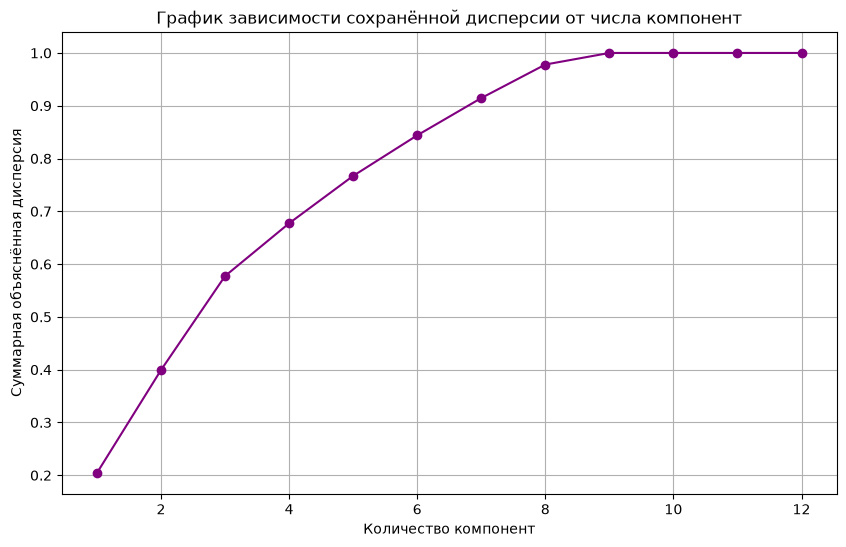

In [ ]:
import matplotlib.pyplot as plt

pipeline_pca_n12 = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(random_state=627, n_components=12)),
    ('model', LinearRegression())
])
pipeline_pca_n12.fit(X_train, y_train)

pca = pipeline_pca_n12.named_steps['pca']
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o',
    color='purple'
)
plt.xlabel('Количество компонент')
plt.ylabel('Суммарная объяснённая дисперсия')
plt.title('График зависимости сохранённой дисперсии от числа компонент')
plt.grid(True)
plt.show()

In [20]:
pipeline_pca_n8 = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(random_state=627, n_components=8)),
    ('model', LinearRegression())
])
res_pca_n8 = evaluate_pipeline(pipeline_pca_n8, X_train, X_test, y_train, y_test)
print(f"Качество на тестовой выборке: r2 = {res_pca_n8['r2']:.4f}, MAE = {res_pca_n8['mae']:.4f}")

Качество на тестовой выборке: r2 = 0.1043, MAE = 0.2587
